In [1]:
import pandas as pd
import numpy as np

In [2]:
# Load processed dataset
df = pd.read_csv("Data/Processed_nassau_candy_data.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Units,Gross Profit,Cost,Lead_Time,Profit_Margin,Revenue_Per_Unit,Unit_Cost,Factory,Factory_Latitude,Factory_Longitude
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,...,2,4.22,2.28,8,0.649231,3.25,1.14,Wicked Choccy's,32.076176,-81.088371
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,2,4.90,2.60,8,0.653333,3.75,1.30,Wicked Choccy's,32.076176,-81.088371
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,3,7.47,3.00,8,0.713467,3.49,1.00,Lot's O' Nuts,32.881893,-111.768036
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,3,7.50,3.30,8,0.694444,3.60,1.10,Lot's O' Nuts,32.881893,-111.768036
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,3,7.35,3.90,7,0.653333,3.75,1.30,Wicked Choccy's,32.076176,-81.088371


In [4]:
df.shape

(10194, 25)

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost', 'Lead_Time', 'Profit_Margin',
       'Revenue_Per_Unit', 'Unit_Cost', 'Factory', 'Factory_Latitude',
       'Factory_Longitude'],
      dtype='object')

In [6]:
df.isnull().sum()

Row ID               0
Order ID             0
Order Date           0
Ship Date            0
Ship Mode            0
Customer ID          0
Country/Region       0
City                 0
State/Province       0
Postal Code          0
Division             0
Region               0
Product ID           0
Product Name         0
Sales                0
Units                0
Gross Profit         0
Cost                 0
Lead_Time            0
Profit_Margin        0
Revenue_Per_Unit     0
Unit_Cost            0
Factory              0
Factory_Latitude     0
Factory_Longitude    0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Row ID             10194 non-null  int64  
 1   Order ID           10194 non-null  object 
 2   Order Date         10194 non-null  object 
 3   Ship Date          10194 non-null  object 
 4   Ship Mode          10194 non-null  object 
 5   Customer ID        10194 non-null  int64  
 6   Country/Region     10194 non-null  object 
 7   City               10194 non-null  object 
 8   State/Province     10194 non-null  object 
 9   Postal Code        10194 non-null  object 
 10  Division           10194 non-null  object 
 11  Region             10194 non-null  object 
 12  Product ID         10194 non-null  object 
 13  Product Name       10194 non-null  object 
 14  Sales              10194 non-null  float64
 15  Units              10194 non-null  int64  
 16  Gross Profit       101

In [8]:
features = [
    "Ship Mode",
    "Region",
    "Division",
    "Factory",
    "Units"
]

target = "Gross Profit"

In [9]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

categorical_cols = [
    "Ship Mode",
    "Region",
    "Division",
    "Factory"
]

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()

    df_model[col] = le.fit_transform(df_model[col])

    encoders[col] = le

In [10]:
from sklearn.model_selection import train_test_split

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8155, 5)
(2039, 5)


In [11]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [12]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MAE : 0.6700
RMSE: 3.0085
R²  : 0.7660


In [13]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

     Feature  Importance
4      Units    0.712771
1     Region    0.094111
2   Division    0.075552
3    Factory    0.065312
0  Ship Mode    0.052254


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

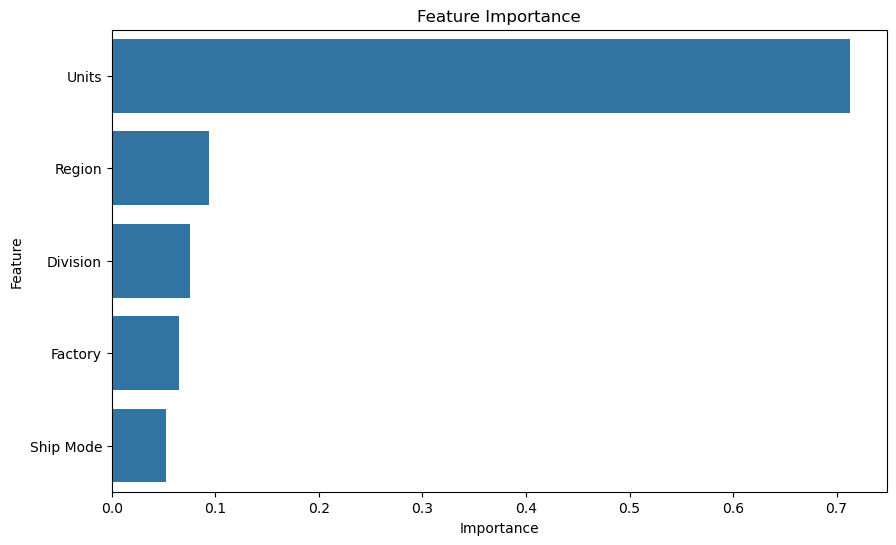

In [15]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()